# Home Credit Default Risk — Exploratory Data Analysis

**Goal:** understand who defaults on a loan and why, before any model gets built.
`TARGET = 1` means the applicant had payment difficulties on the current loan; `TARGET = 0` means they didn't.

This notebook covers:
1. Loading the data, checking it's sound, and a quick inventory of what else is available
2. Target distribution and what the imbalance means for modelling
3. Data quality — missing values, a few known data issues, and how they're handled
4. Demographics — age, gender, family, education, income type, housing type
5. Financials — income, credit amount, and the ratios between them
6. External credit bureau scores
7. Repayment history from the other tables (`bureau.csv`, `previous_application.csv`, `installments_payments.csv`)
8. A quick model-free look at which features correlate with default
9. Insights and what to carry into the modelling stage

Only `application_train.csv` is required to run this end-to-end. Everything that depends on the
other files is written to skip gracefully if that file isn't present in `data/`.

## 0. Setup

Nothing fancy — just imports and a couple of constants used throughout the notebook.
`DATA_DIR` points at the local `data/` folder (adjust if your files live elsewhere).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)

DATA_DIR = Path('data')          # change this if your CSVs live somewhere else
TARGET = 'TARGET'
MIN_SEGMENT_N = 500              # ignore categories with fewer applicants than this — too noisy to trust
COLOR_REPAID = '#2ecc71'
COLOR_DEFAULT = '#e74c3c'

## 1. Loading the data, sanity checks, and what else is available

Before doing anything with the data, it's worth checking the basics: does every row have a unique
applicant ID, is the target actually filled in for every row, and are there any exact duplicate rows.
Also worth confirming there's no overlap between train and test applicant IDs — if there were, that
would be a leakage problem.

In [2]:
app = pd.read_csv(DATA_DIR / 'application_train.csv')
print(f"Shape: {app.shape[0]:,} rows x {app.shape[1]} columns")
app.head()

Shape: 307,511 rows x 122 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

In [3]:
print(f"Duplicate SK_ID_CURR values : {app['SK_ID_CURR'].duplicated().sum()}")
print(f"Missing TARGET values       : {app[TARGET].isna().sum()}")
print(f"Fully duplicated rows       : {app.duplicated().sum()}")

test_path = DATA_DIR / 'application_test.csv'
if test_path.exists():
    test_ids = pd.read_csv(test_path, usecols=['SK_ID_CURR'])
    overlap = app['SK_ID_CURR'].isin(test_ids['SK_ID_CURR']).sum()
    print(f"Train/test SK_ID_CURR overlap : {overlap} (should be 0)")
else:
    print("application_test.csv not found — skipping the train/test overlap check")

Duplicate SK_ID_CURR values : 0
Missing TARGET values       : 0


Fully duplicated rows       : 0
Train/test SK_ID_CURR overlap : 0 (should be 0)


Good — one row per applicant, no missing targets, no duplicate rows, and no ID overlap with the test set (when it's available to check). Safe to move on.

A quick note on what else is in the Home Credit dataset, and whether each file is actually sitting
in `data/` right now. Not all of these get used below — `bureau_balance.csv`, `POS_CASH_balance.csv`
and `credit_card_balance.csv` are left out to keep this notebook focused, but it's useful to know
they exist for a future iteration.

In [4]:
file_specs = {
    'application_train.csv':   ('One row per loan application — the main table, and the only one used for TARGET', 'SK_ID_CURR'),
    'application_test.csv':    ('Same as above, unlabeled — used here only for the leakage check', 'SK_ID_CURR'),
    'bureau.csv':               ('One row per credit the applicant has with any lender, reported to the bureau', 'SK_ID_BUREAU'),
    'bureau_balance.csv':       ('Monthly balance history for each bureau credit (not used below)', 'SK_ID_BUREAU + month'),
    'previous_application.csv': ('One row per previous application the applicant made with Home Credit', 'SK_ID_PREV'),
    'POS_CASH_balance.csv':     ('Monthly balance snapshot for point-of-sale/cash loans (not used below)', 'SK_ID_PREV + month'),
    'credit_card_balance.csv':  ('Monthly balance snapshot for credit cards (not used below)', 'SK_ID_PREV + month'),
    'installments_payments.csv': ('One row per scheduled/actual instalment payment', 'SK_ID_PREV + instalment number'),
}

inventory = pd.DataFrame([
    {'file': f, 'description': desc, 'grain': grain, 'present_in_data_folder': (DATA_DIR / f).exists()}
    for f, (desc, grain) in file_specs.items()
])
inventory

,file,description,grain,present_in_data_folder
0,application_train.csv,"One row per loan application — the main table,...",SK_ID_CURR,True
1,application_test.csv,"Same as above, unlabeled — used here only for ...",SK_ID_CURR,True
2,bureau.csv,One row per credit the applicant has with any ...,SK_ID_BUREAU,True
3,bureau_balance.csv,Monthly balance history for each bureau credit...,SK_ID_BUREAU + month,True
4,previous_application.csv,One row per previous application the applicant...,SK_ID_PREV,True
5,POS_CASH_balance.csv,Monthly balance snapshot for point-of-sale/cas...,SK_ID_PREV + month,True
6,credit_card_balance.csv,Monthly balance snapshot for credit cards (not...,SK_ID_PREV + month,True
7,installments_payments.csv,One row per scheduled/actual instalment payment,SK_ID_PREV + instalment number,True


## 2. Target distribution

This is the first thing to check in any classification problem: how balanced is the target?

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\2771248723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET, data=app, palette=[COLOR_REPAID, COLOR_DEFAULT])


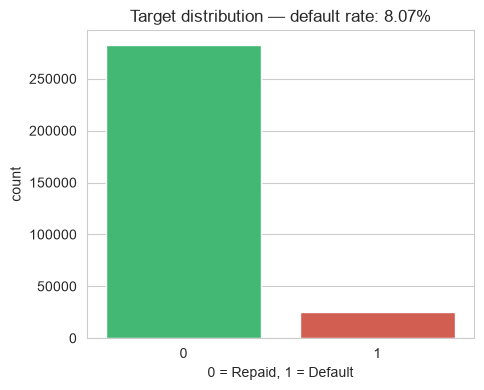

In [5]:
target_pct = app[TARGET].value_counts(normalize=True) * 100
default_rate = app[TARGET].mean()
print(target_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=app, palette=[COLOR_REPAID, COLOR_DEFAULT])
plt.title(f"Target distribution — default rate: {default_rate:.2%}")
plt.xlabel('0 = Repaid, 1 = Default')
plt.show()

Only around 8% of applicants default — this is a strongly imbalanced problem. Plain accuracy would be
a useless metric here (a model that just predicts "repaid" every time would already score ~92%).
Whatever model we build later should be evaluated with ROC-AUC / PR-AUC, and trained with
`class_weight` or similar so the minority class actually gets learned.

## 3. Data quality

A few checks before trusting any of the columns: how much is missing, whether any columns are
basically useless (constant or empty), a rough grouping of what kind of information each column
holds, and a couple of specific known issues in this dataset (an `XNA` gender code, and a
placeholder value in `DAYS_EMPLOYED`).

67 of 122 columns have at least one missing value
Columns with >40% missing : 49
Near-constant columns     : 0 (0 or 1 unique value — not useful for modelling)


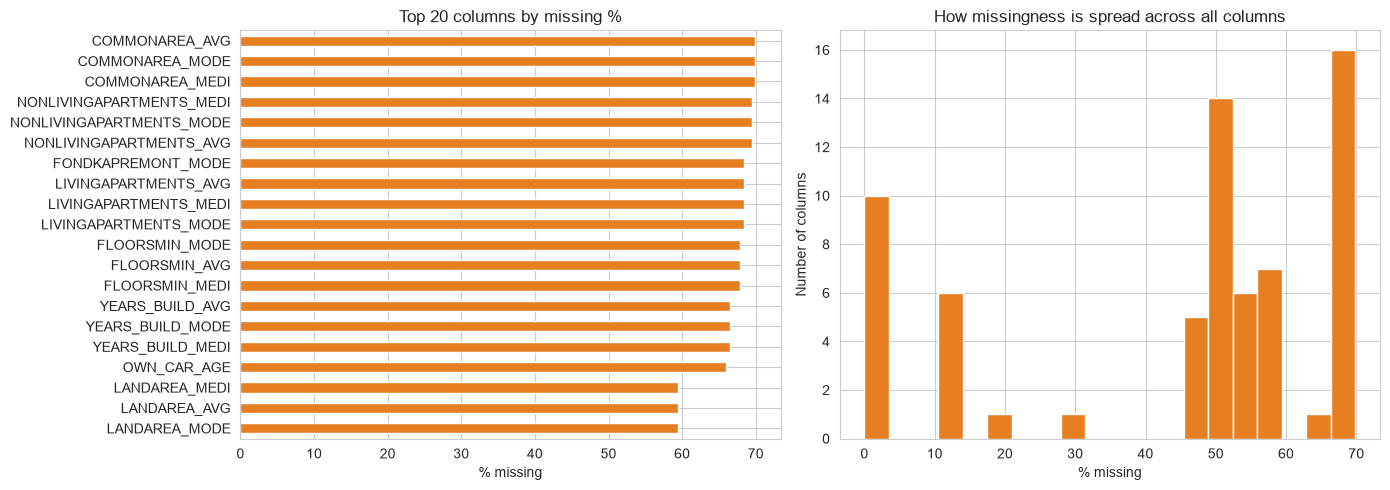

In [6]:
missing_pct = app.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
near_constant_cols = (app.nunique(dropna=False) <= 1).sum()

print(f"{len(missing_pct)} of {app.shape[1]} columns have at least one missing value")
print(f"Columns with >40% missing : {(missing_pct > 40).sum()}")
print(f"Near-constant columns     : {near_constant_cols} (0 or 1 unique value — not useful for modelling)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_pct.head(20).plot(kind='barh', color='#e67e22', ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_xlabel('% missing')
axes[0].set_title('Top 20 columns by missing %')

axes[1].hist(missing_pct, bins=20, color='#e67e22')
axes[1].set_xlabel('% missing')
axes[1].set_ylabel('Number of columns')
axes[1].set_title('How missingness is spread across all columns')

plt.tight_layout()
plt.show()

The heaviest-missing columns are mostly building/apartment characteristics (`*_AVG`, `*_MODE`,
`*_MEDI`) and the external bureau scores. The second chart shows most of the missing-value columns
are clustered around the same missing % — likely one underlying reason (e.g. a form section that's
often skipped) rather than many unrelated ones. These will need either imputation or a "missing"
indicator flag rather than being dropped outright, since a few of them (especially `EXT_SOURCE_*`)
turn out to matter a lot for the target (see Section 6).

In [7]:
def feature_family(col):
    """Rough grouping of columns by what kind of information they hold — just for orientation,
    not used anywhere downstream."""
    if col == TARGET:
        return 'Target'
    if col.startswith('SK_ID'):
        return 'Identifier'
    if col.startswith('EXT_SOURCE'):
        return 'External score'
    if col.startswith(('AMT_', 'CNT_')):
        return 'Financial / household amount'
    if col.startswith(('DAYS_', 'REGION_RATING')):
        return 'Time / regional risk'
    if col.startswith('FLAG_'):
        return 'Document / contact flag'
    if app[col].dtype == object:
        return 'Categorical'
    return 'Other numeric'

family_counts = pd.Series({c: feature_family(c) for c in app.columns}).value_counts()
family_counts

Other numeric                   70
Document / contact flag         28
Financial / household amount    12
Time / regional risk             7
External score                   3
Identifier                       1
Target                           1
Name: count, dtype: int64

In [8]:
app['AGE_YEARS'] = -app['DAYS_BIRTH'] / 365.25

quality_checks = pd.DataFrame({
    'issue': [
        'CODE_GENDER = "XNA" (unspecified)',
        'Non-positive AMT_INCOME_TOTAL',
        'Age outside 18-100 years',
        'DAYS_EMPLOYED = 365243 (placeholder)',
    ],
    'rows': [
        app['CODE_GENDER'].eq('XNA').sum(),
        app['AMT_INCOME_TOTAL'].le(0).sum(),
        (~app['AGE_YEARS'].between(18, 100)).sum(),
        app['DAYS_EMPLOYED'].eq(365243).sum(),
    ],
})
quality_checks['share_of_rows'] = quality_checks['rows'] / len(app)
quality_checks

C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\3367938677.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['AGE_YEARS'] = -app['DAYS_BIRTH'] / 365.25


,issue,rows,share_of_rows
0,"CODE_GENDER = ""XNA"" (unspecified)",4,0.000013
1,Non-positive AMT_INCOME_TOTAL,0,0.000000
2,Age outside 18-100 years,0,0.000000
3,DAYS_EMPLOYED = 365243 (placeholder),55374,0.180072


`DAYS_EMPLOYED = 365243` is Home Credit's placeholder for "not currently employed" (mostly
pensioners) — left as-is, it would badly distort any mean/median or correlation involving this
column, so it gets flagged and swapped for `NaN` here before it's used anywhere else. The other
three issues above affect a small enough share of rows that they're just noted rather than dropped
or corrected — worth knowing about, not worth losing data over.

In [9]:
app['DAYS_EMPLOYED_ANOM'] = app['DAYS_EMPLOYED'].eq(365243)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace({365243: np.nan})

C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\996604393.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['DAYS_EMPLOYED_ANOM'] = app['DAYS_EMPLOYED'].eq(365243)


## 4. Demographics

How does the applicant profile — age, gender, family situation, education, income type, housing —
relate to default?

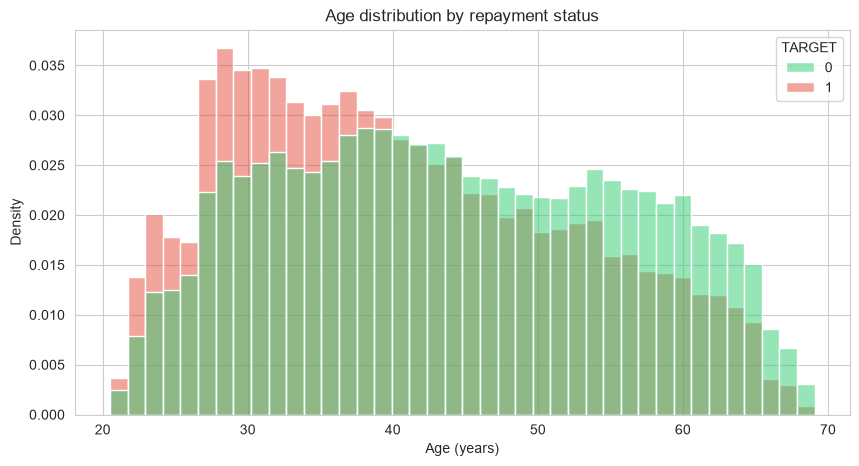

TARGET
0    43.468857
1    39.101985
Name: AGE_YEARS, dtype: float64


In [10]:
plt.figure()
sns.histplot(data=app, x='AGE_YEARS', hue=TARGET, bins=40, stat='density',
             common_norm=False, palette=[COLOR_REPAID, COLOR_DEFAULT])
plt.title('Age distribution by repayment status')
plt.xlabel('Age (years)')
plt.show()

print(app.groupby(TARGET)['AGE_YEARS'].median())

C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\1795377695.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['AGE_BAND'] = pd.cut(app['AGE_YEARS'], bins=age_bins, labels=age_labels, right=False)


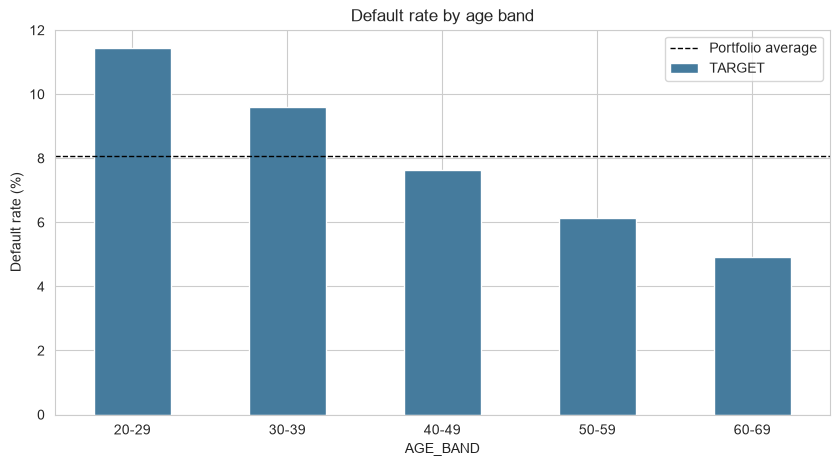

In [11]:
age_bins = [20, 30, 40, 50, 60, 70, 100]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70+']
app['AGE_BAND'] = pd.cut(app['AGE_YEARS'], bins=age_bins, labels=age_labels, right=False)

age_default = app.groupby('AGE_BAND')[TARGET].mean() * 100
age_default.plot(kind='bar', color='#457B9D')
plt.axhline(default_rate * 100, color='black', linestyle='--', linewidth=1, label='Portfolio average')
plt.ylabel('Default rate (%)')
plt.title('Default rate by age band')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Younger applicants default noticeably more than older ones — makes sense, less credit history and often less income stability at that stage.

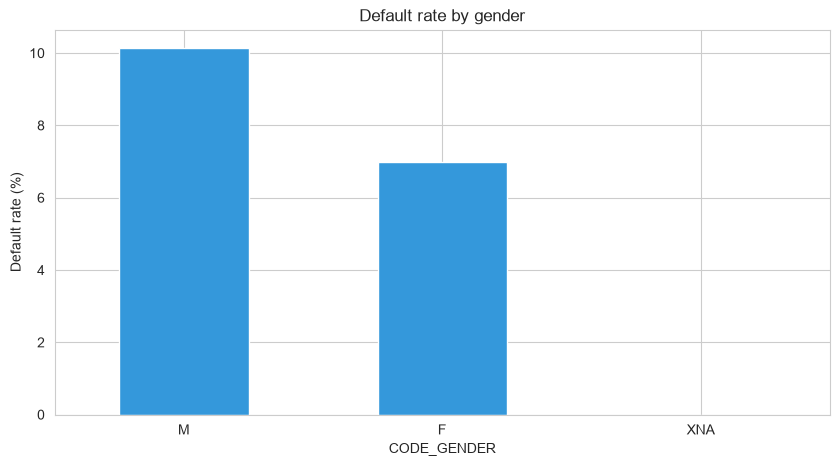

In [12]:
gender_default = app.groupby('CODE_GENDER')[TARGET].mean().sort_values(ascending=False) * 100
gender_default.plot(kind='bar', color='#3498db')
plt.ylabel('Default rate (%)')
plt.title('Default rate by gender')
plt.xticks(rotation=0)
plt.show()

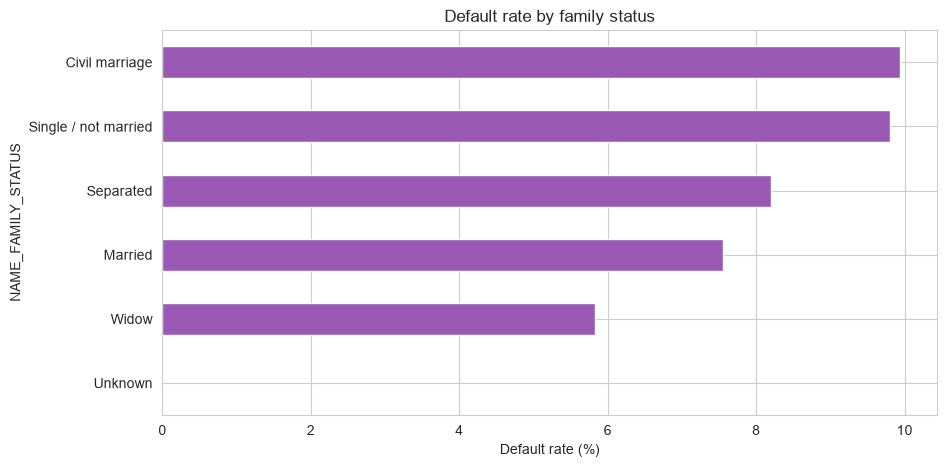

In [13]:
fam_default = app.groupby('NAME_FAMILY_STATUS')[TARGET].mean().sort_values(ascending=False) * 100
fam_default.plot(kind='barh', color='#9b59b6')
plt.xlabel('Default rate (%)')
plt.title('Default rate by family status')
plt.gca().invert_yaxis()
plt.show()

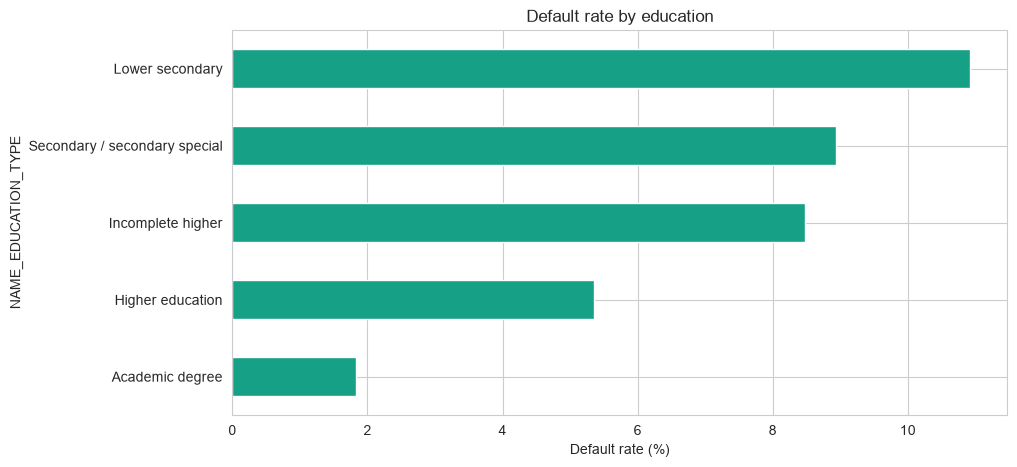

In [14]:
edu_default = app.groupby('NAME_EDUCATION_TYPE')[TARGET].mean().sort_values(ascending=False) * 100
edu_default.plot(kind='barh', color='#16a085')
plt.xlabel('Default rate (%)')
plt.title('Default rate by education')
plt.gca().invert_yaxis()
plt.show()

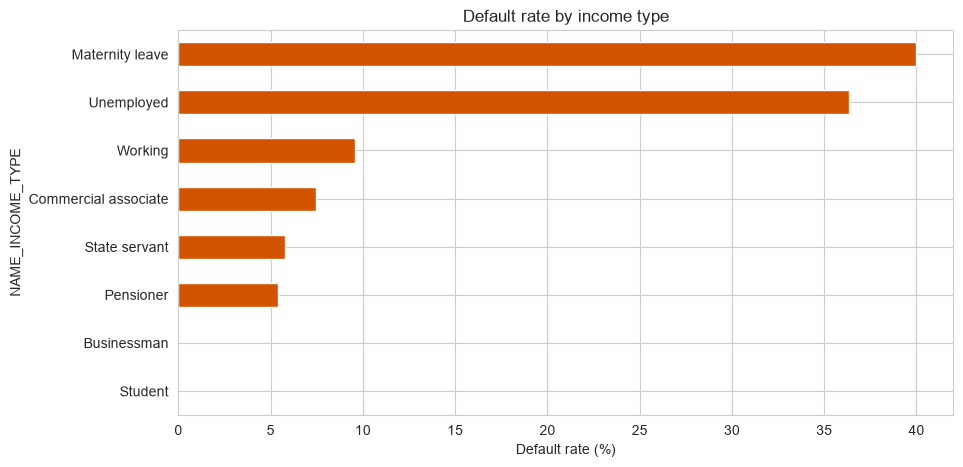

In [15]:
income_type_default = app.groupby('NAME_INCOME_TYPE')[TARGET].mean().sort_values(ascending=False) * 100
income_type_default.plot(kind='barh', color='#d35400')
plt.xlabel('Default rate (%)')
plt.title('Default rate by income type')
plt.gca().invert_yaxis()
plt.show()

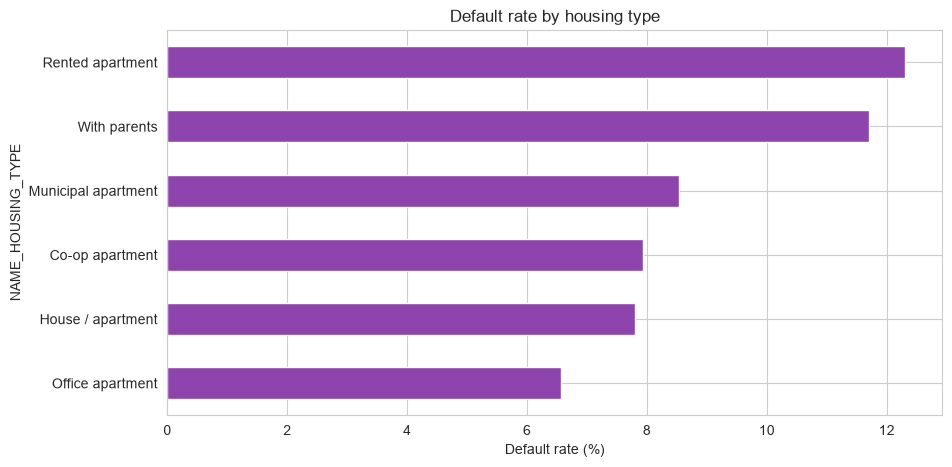

In [16]:
housing_default = app.groupby('NAME_HOUSING_TYPE')[TARGET].mean().sort_values(ascending=False) * 100
housing_default.plot(kind='barh', color='#8e44ad')
plt.xlabel('Default rate (%)')
plt.title('Default rate by housing type')
plt.gca().invert_yaxis()
plt.show()

The charts above show the direction of each effect; the table below adds the piece a bar chart can't
show — how many applicants are actually behind each number, and how far each segment sits from the
portfolio average ("lift" — 1.5x means 50% more likely to default than the average applicant).
Segments with fewer than 500 applicants are dropped since their rates aren't reliable.

In [17]:
def segment_default_rate(df, col, min_n=MIN_SEGMENT_N):
    g = df.groupby(col)[TARGET].agg(n='count', default_rate='mean').reset_index()
    g = g[g['n'] >= min_n].copy()
    g['default_rate'] = g['default_rate'] * 100
    g['lift_vs_portfolio'] = g['default_rate'] / (default_rate * 100)
    g = g.rename(columns={col: 'segment'})
    g.insert(0, 'feature', col)
    return g.sort_values('default_rate', ascending=False)

segment_cols = ['CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_HOUSING_TYPE']
segment_summary = pd.concat([segment_default_rate(app, c) for c in segment_cols], ignore_index=True)
segment_summary.round(2)

,feature,segment,n,default_rate,lift_vs_portfolio
0,CODE_GENDER,M,105059,10.14,1.26
1,CODE_GENDER,F,202448,7.00,0.87
2,NAME_FAMILY_STATUS,Civil marriage,29775,9.94,1.23
3,NAME_FAMILY_STATUS,Single / not married,45444,9.81,1.21
4,NAME_FAMILY_STATUS,Separated,19770,8.19,1.02
5,NAME_FAMILY_STATUS,Married,196432,7.56,0.94
6,NAME_FAMILY_STATUS,Widow,16088,5.82,0.72
7,NAME_EDUCATION_TYPE,Lower secondary,3816,10.93,1.35
8,NAME_EDUCATION_TYPE,Secondary / secondary special,218391,8.94,1.11
9,NAME_EDUCATION_TYPE,Incomplete higher,10277,8.48,1.05


> **Worth flagging:** gender, family status and age are the kind of attributes that need extra care
> when they show up as "predictive" — using them directly in a lending decision can raise fairness
> and compliance issues. Good to know they correlate with risk, not a green light to build rules on top of them.

## 5. Financials

Income, credit amount, annuity, and the ratios between them — usually where the strongest
signal in this dataset lives.

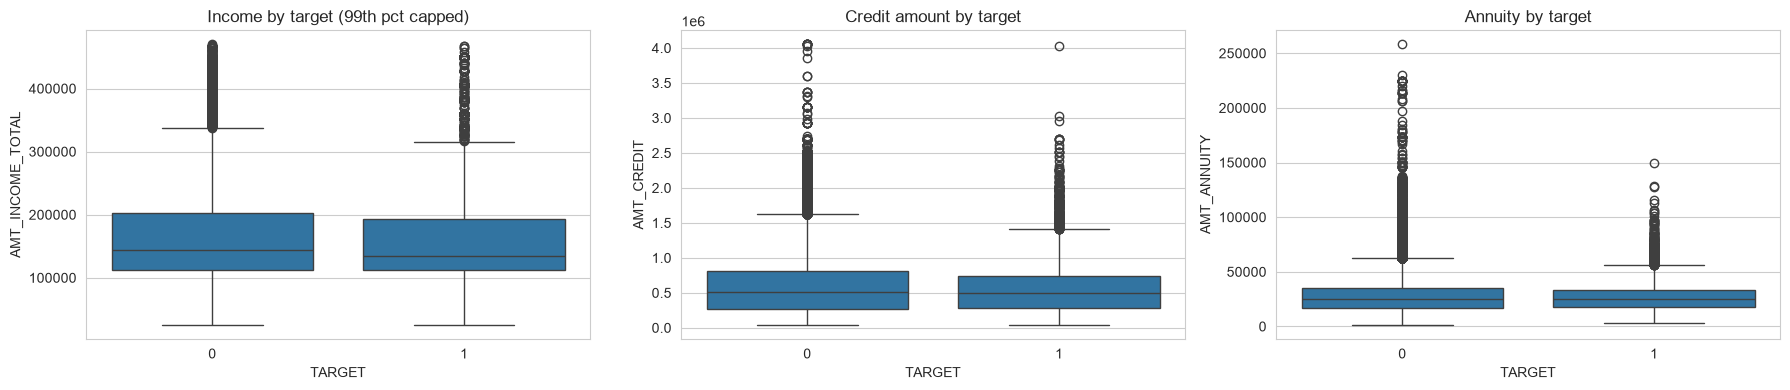

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

income_capped = app[app['AMT_INCOME_TOTAL'] < app['AMT_INCOME_TOTAL'].quantile(0.99)]
sns.boxplot(x=TARGET, y='AMT_INCOME_TOTAL', data=income_capped, ax=axes[0])
axes[0].set_title('Income by target (99th pct capped)')

sns.boxplot(x=TARGET, y='AMT_CREDIT', data=app, ax=axes[1])
axes[1].set_title('Credit amount by target')

sns.boxplot(x=TARGET, y='AMT_ANNUITY', data=app.dropna(subset=['AMT_ANNUITY']), ax=axes[2])
axes[2].set_title('Annuity by target')

plt.tight_layout()
plt.show()

In [19]:
def safe_ratio(numerator, denominator):
    """Regular division, but returns NaN instead of inf when the denominator is 0."""
    return numerator / denominator.where(denominator != 0)

app['CREDIT_INCOME_RATIO'] = safe_ratio(app['AMT_CREDIT'], app['AMT_INCOME_TOTAL'])
app['ANNUITY_INCOME_RATIO'] = safe_ratio(app['AMT_ANNUITY'], app['AMT_INCOME_TOTAL'])
app['CREDIT_TERM'] = safe_ratio(app['AMT_ANNUITY'], app['AMT_CREDIT'])
app['CREDIT_GOODS_RATIO'] = safe_ratio(app['AMT_CREDIT'], app['AMT_GOODS_PRICE'])
app['EMPLOYED_AGE_RATIO'] = safe_ratio(-app['DAYS_EMPLOYED'], app['AGE_YEARS'] * 365.25)

ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'CREDIT_GOODS_RATIO', 'EMPLOYED_AGE_RATIO']
app.groupby(TARGET)[ratio_cols].median()

C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\4218996520.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['CREDIT_INCOME_RATIO'] = safe_ratio(app['AMT_CREDIT'], app['AMT_INCOME_TOTAL'])
C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\4218996520.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['ANNUITY_INCOME_RATIO'] = safe_ratio(app['AMT_ANNUITY'], app['AMT_INCOME_TOTAL'])
C:\Users\sancr\AppData\Local\Temp\ipykernel_16540\4218996520.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,CREDIT_GOODS_RATIO,EMPLOYED_AGE_RATIO
TARGET,,,,,
0,3.266653,0.162280,0.05,1.1188,0.121592
1,3.253143,0.169294,0.05,1.1452,0.093461


Raw income and credit amount don't separate the two groups very cleanly on their own (both
distributions overlap a lot). The ratios are more useful — applicants who default tend to be
borrowing a larger multiple of their income, which is intuitive: it's not the loan size that
matters so much as how big it is relative to what the person earns. `EMPLOYED_AGE_RATIO` is `NaN`
for pensioners (no current employment to divide by), which is expected, not a bug.

## 6. External credit scores

`EXT_SOURCE_1/2/3` are normalized scores from external data sources (credit bureaus, most likely).
Rather than just comparing medians, it's more useful to bucket applicants into deciles by score and
plot the default rate per bucket — this shows whether the relationship is a clean trend or something
messier.

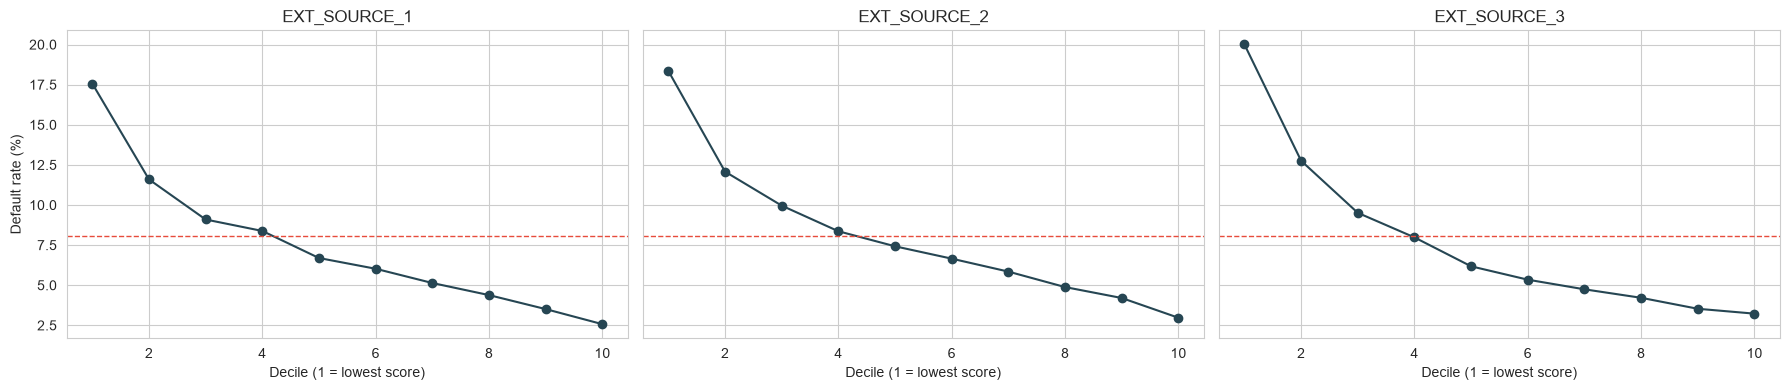

EXT_SOURCE_1   -0.155317
EXT_SOURCE_2   -0.160472
EXT_SOURCE_3   -0.178919
TARGET          1.000000
Name: TARGET, dtype: float64

In [20]:
def decile_default_rate(df, col, q=10):
    valid = df.dropna(subset=[col]).copy()
    valid['bucket'] = pd.qcut(valid[col], q=q, duplicates='drop')
    return valid.groupby('bucket', observed=True)[TARGET].mean() * 100

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, col in zip(axes, ext_cols):
    rates = decile_default_rate(app, col)
    ax.plot(range(1, len(rates) + 1), rates.values, marker='o', color='#264653')
    ax.axhline(default_rate * 100, color=COLOR_DEFAULT, linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_xlabel('Decile (1 = lowest score)')
axes[0].set_ylabel('Default rate (%)')
plt.tight_layout()
plt.show()

app[ext_cols + [TARGET]].corr()[TARGET]

A clean downward trend across all three — the lowest-scoring decile defaults several times more often than the highest. These are clearly some of the strongest predictors available and are worth prioritizing (and imputing carefully, given their missingness — see Section 3).

## 7. Repayment history from the other tables

`application_train.csv` only describes the current loan. The other tables carry the applicant's
history with Home Credit and other lenders, which is arguably more informative than anything in
the main table. These are aggregated to one row per applicant and merged in — each block below
runs only if the corresponding file is available.

In [21]:
bureau_path = DATA_DIR / 'bureau.csv'

if bureau_path.exists():
    bureau = pd.read_csv(bureau_path, usecols=['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_DAY_OVERDUE'])
    bureau['IS_ACTIVE'] = bureau['CREDIT_ACTIVE'].eq('Active').astype(int)
    bureau['HAS_OVERDUE'] = bureau['CREDIT_DAY_OVERDUE'].gt(0).astype(int)

    bureau_agg = bureau.groupby('SK_ID_CURR').agg(
        PRIOR_CREDIT_COUNT=('SK_ID_BUREAU', 'count'),
        ACTIVE_CREDIT_COUNT=('IS_ACTIVE', 'sum'),
        OVERDUE_SHARE=('HAS_OVERDUE', 'mean'),
    ).reset_index()
    app = app.merge(bureau_agg, on='SK_ID_CURR', how='left')
    print(f"Bureau history found for {bureau_agg.shape[0]:,} of {app.shape[0]:,} applicants")
else:
    print("bureau.csv not found — skipping this block")

Bureau history found for 305,811 of 307,511 applicants


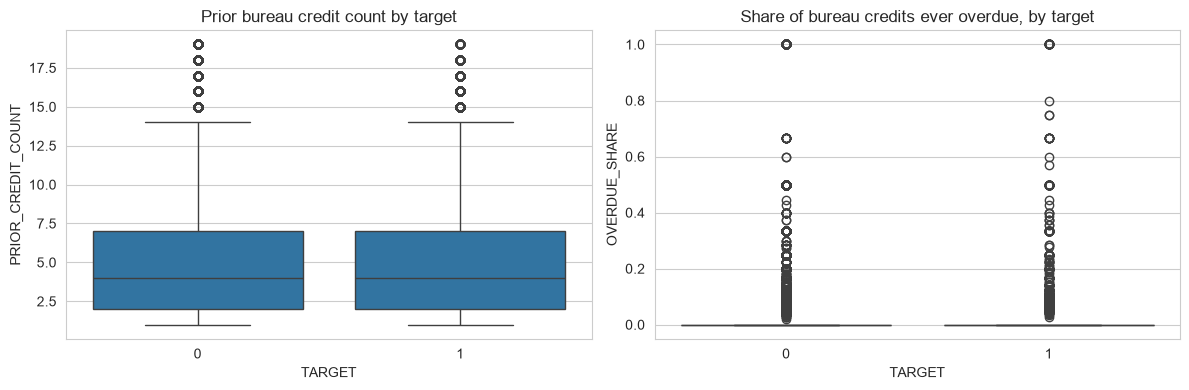

In [22]:
if 'PRIOR_CREDIT_COUNT' in app.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    capped = app[app['PRIOR_CREDIT_COUNT'] < app['PRIOR_CREDIT_COUNT'].quantile(0.99)]
    sns.boxplot(x=TARGET, y='PRIOR_CREDIT_COUNT', data=capped, ax=axes[0])
    axes[0].set_title('Prior bureau credit count by target')

    sns.boxplot(x=TARGET, y='OVERDUE_SHARE', data=app.dropna(subset=['OVERDUE_SHARE']), ax=axes[1])
    axes[1].set_title('Share of bureau credits ever overdue, by target')

    plt.tight_layout()
    plt.show()

In [23]:
prev_path = DATA_DIR / 'previous_application.csv'

if prev_path.exists():
    prev = pd.read_csv(prev_path, usecols=['SK_ID_CURR', 'NAME_CONTRACT_STATUS'])
    prev_agg = prev.groupby('SK_ID_CURR').agg(
        PREV_APP_COUNT=('NAME_CONTRACT_STATUS', 'count'),
        PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    ).reset_index()
    prev_agg['PREV_REFUSAL_RATE'] = prev_agg['PREV_REFUSED_COUNT'] / prev_agg['PREV_APP_COUNT']
    app = app.merge(prev_agg, on='SK_ID_CURR', how='left')
    print(f"Previous application history found for {prev_agg.shape[0]:,} applicants")
else:
    print("previous_application.csv not found — skipping this block")

Previous application history found for 338,857 applicants


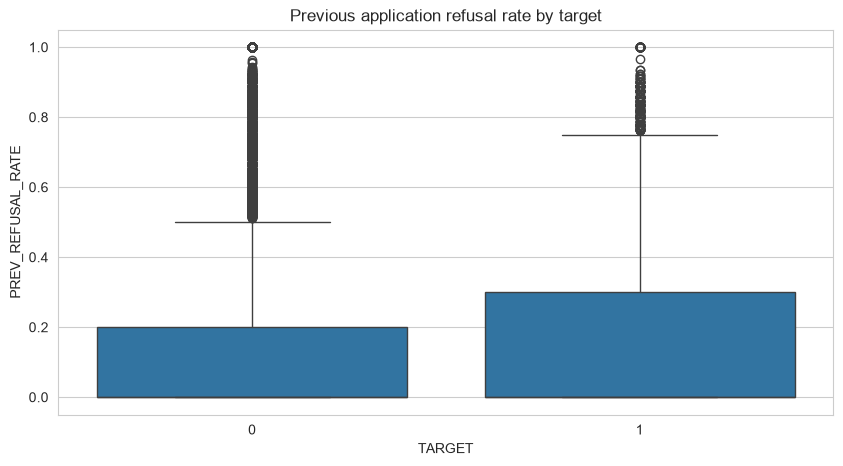

In [24]:
if 'PREV_REFUSAL_RATE' in app.columns:
    plt.figure()
    sns.boxplot(x=TARGET, y='PREV_REFUSAL_RATE', data=app.dropna(subset=['PREV_REFUSAL_RATE']))
    plt.title('Previous application refusal rate by target')
    plt.show()

`installments_payments.csv` is the biggest of these files (tens of millions of rows in the full
dataset), so it's read and aggregated in chunks rather than all at once — each chunk contributes
its own partial counts, which are summed up at the end to get the true per-applicant rate.

In [25]:
inst_path = DATA_DIR / 'installments_payments.csv'

if inst_path.exists():
    usecols = ['SK_ID_CURR', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']
    chunk_aggs = []

    for chunk in pd.read_csv(inst_path, usecols=usecols, chunksize=2_000_000):
        chunk['LATE'] = (chunk['DAYS_ENTRY_PAYMENT'] > chunk['DAYS_INSTALMENT']).astype(int)
        chunk['UNDERPAID'] = (chunk['AMT_PAYMENT'] < chunk['AMT_INSTALMENT']).astype(int)
        part = chunk.groupby('SK_ID_CURR').agg(
            N=('LATE', 'count'), LATE_SUM=('LATE', 'sum'), UNDERPAID_SUM=('UNDERPAID', 'sum')
        )
        chunk_aggs.append(part)

    inst_agg = pd.concat(chunk_aggs).groupby('SK_ID_CURR').sum()
    inst_agg['INST_LATE_RATE'] = inst_agg['LATE_SUM'] / inst_agg['N']
    inst_agg['INST_UNDERPAY_RATE'] = inst_agg['UNDERPAID_SUM'] / inst_agg['N']
    inst_agg = inst_agg[['INST_LATE_RATE', 'INST_UNDERPAY_RATE']].reset_index()

    app = app.merge(inst_agg, on='SK_ID_CURR', how='left')
    print(f"Instalment history found for {inst_agg.shape[0]:,} applicants")
else:
    print("installments_payments.csv not found — skipping this block")

Instalment history found for 339,587 applicants


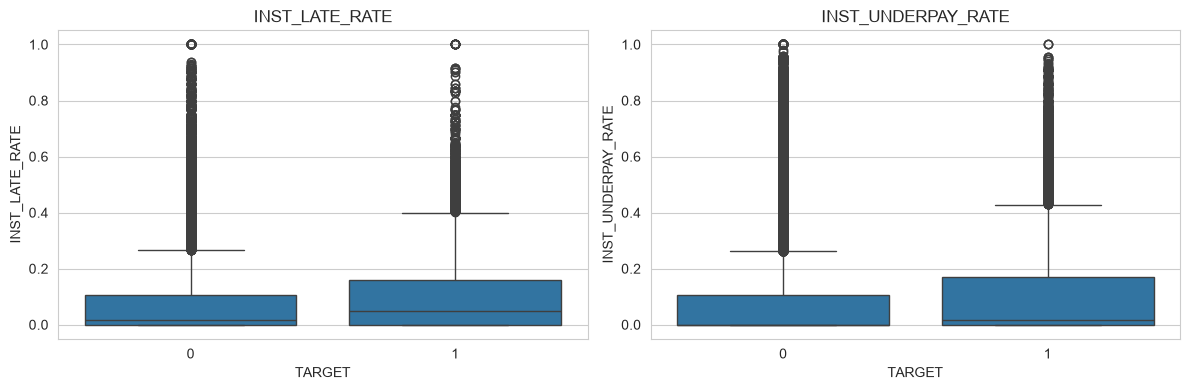

In [26]:
history_cols = [c for c in ['INST_LATE_RATE', 'INST_UNDERPAY_RATE'] if c in app.columns]
if history_cols:
    fig, axes = plt.subplots(1, len(history_cols), figsize=(6 * len(history_cols), 4))
    if len(history_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, history_cols):
        sns.boxplot(x=TARGET, y=col, data=app.dropna(subset=[col]), ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

As expected, applicants with more prior refusals, more late instalments, and a higher underpayment rate skew towards default — this repayment behaviour is a much stronger signal than anything demographic.

## 8. Quick correlation scan

Point-biserial correlation is a fast, model-free way to rank features by linear association with
the target. It won't catch non-linear effects, but it's a good first pass before spending time on
a full model.

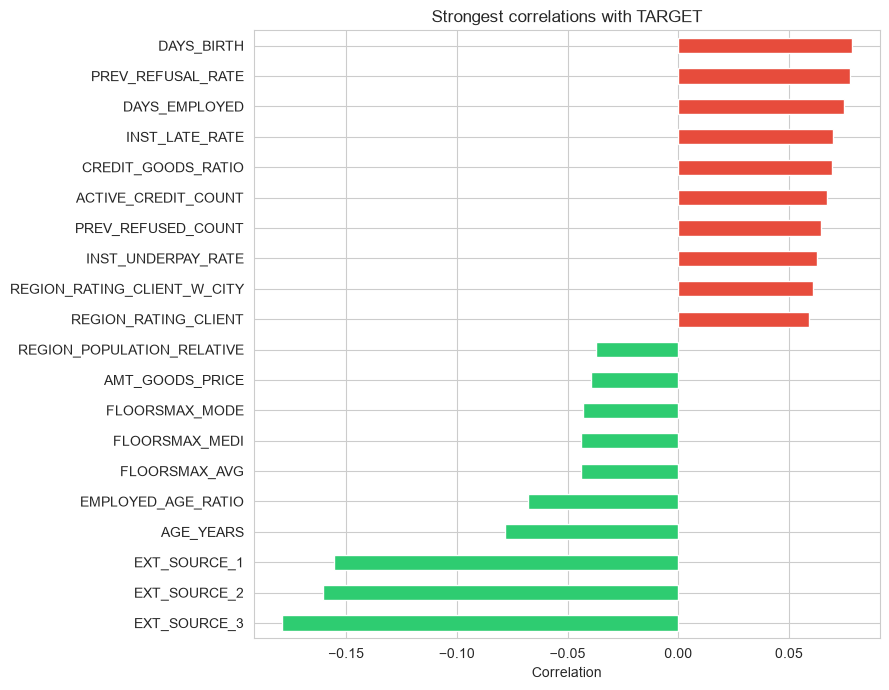

In [27]:
numeric_app = app.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
drop_cols = [c for c in numeric_app.columns if c == TARGET or c.startswith('SK_ID')]
correlations = numeric_app.drop(columns=drop_cols).corrwith(app[TARGET]).dropna().sort_values()

top_corr = pd.concat([correlations.head(10), correlations.tail(10)])
colors = [COLOR_REPAID if v < 0 else COLOR_DEFAULT for v in top_corr.values]

plt.figure(figsize=(9, 7))
top_corr.plot(kind='barh', color=colors)
plt.title('Strongest correlations with TARGET')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## 9. Key insights

Pulling together what the sections above showed, computed from this run so the numbers below
always match what's printed above.

In [28]:
top_age_band = age_default.idxmax()
top_age_rate = age_default.max()
ext_best = app[ext_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs().idxmax()
top_segment = segment_summary.sort_values('lift_vs_portfolio', ascending=False).iloc[0]

insights = f"""
1. Default is a minority event ({default_rate:.1%} of applicants) — this needs imbalance-aware
   training (class weights / resampling) and evaluation with ROC-AUC or PR-AUC, not accuracy.
2. Risk is not flat across age: the {top_age_band} band has the highest default rate at
   {top_age_rate:.1f}%, versus a portfolio average of {default_rate * 100:.1f}%.
3. Across all demographic segments checked, {top_segment['segment']} ({top_segment['feature']})
   has the highest lift at {top_segment['lift_vs_portfolio']:.2f}x the portfolio average,
   based on {int(top_segment['n']):,} applicants.
4. Loan-to-income and annuity-to-income ratios separate the two groups more clearly than raw
   income or credit amount — it's the size of the loan relative to earnings that matters, not
   the absolute numbers.
5. {ext_best} is the strongest of the three external scores in this sample and should be
   prioritized in the model (and imputed carefully given its missingness — see Section 3).
6. Prior repayment behaviour (bureau overdue share, previous-application refusals, late
   instalments) is a stronger signal than anything demographic — these engineered features are
   worth the extra join effort.
"""
print(insights)


1. Default is a minority event (8.1% of applicants) — this needs imbalance-aware
   training (class weights / resampling) and evaluation with ROC-AUC or PR-AUC, not accuracy.
2. Risk is not flat across age: the 20-29 band has the highest default rate at
   11.4%, versus a portfolio average of 8.1%.
3. Across all demographic segments checked, Rented apartment (NAME_HOUSING_TYPE)
   has the highest lift at 1.53x the portfolio average,
   based on 4,881 applicants.
4. Loan-to-income and annuity-to-income ratios separate the two groups more clearly than raw
   income or credit amount — it's the size of the loan relative to earnings that matters, not
   the absolute numbers.
5. EXT_SOURCE_3 is the strongest of the three external scores in this sample and should be
   prioritized in the model (and imputed carefully given its missingness — see Section 3).
6. Prior repayment behaviour (bureau overdue share, previous-application refusals, late
   instalments) is a stronger signal than anything

## 10. Handoff to modelling

Features engineered in this notebook that the modelling pipeline should reproduce:

- `AGE_YEARS`, `AGE_BAND` (from `DAYS_BIRTH`)
- `DAYS_EMPLOYED_ANOM` flag + `DAYS_EMPLOYED` anomaly (365243) replaced with `NaN`
- `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `CREDIT_TERM`, `CREDIT_GOODS_RATIO`, `EMPLOYED_AGE_RATIO`
- Bureau aggregates: `PRIOR_CREDIT_COUNT`, `ACTIVE_CREDIT_COUNT`, `OVERDUE_SHARE`
- Previous-application aggregates: `PREV_APP_COUNT`, `PREV_REFUSED_COUNT`, `PREV_REFUSAL_RATE`
- Instalment aggregates: `INST_LATE_RATE`, `INST_UNDERPAY_RATE`

**Guardrails for the next stage:**
- Treat this as an imbalanced classification problem from the start — accuracy is not a useful metric.
- Impute or flag missingness for `EXT_SOURCE_*` rather than dropping the columns; they're too predictive to lose.
- Keep demographic features (age, gender, family status) out of any automated decision rule, even
  if they show up as correlated with the target — that's a fairness/compliance discussion, not a modelling one.
- A simple baseline (logistic regression with class weighting) is a good sanity check before moving to
  gradient boosting.